# Importing the Libraries and loading the dataset

In [1]:
import pandas as pd
import numpy as np
import re
import os

# Load the raw dataset
df = pd.read_csv("data/swiggy.csv")

# Display first 5 rows
df.head()

,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


Basic Dataset Insight

• Restaurant details: name, city, rating, rating count, cost, and cuisine
• Rating: values like 4.1, 4.5, and invalid entries like --
• Rating Count: values like 50+ ratings, 100+ ratings
• Cost: values include the ₹ symbol
• Missing values are present in the dataset
• Duplicate values were checked during preprocessing

# Check the shape

In [2]:
df.shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 148541
Number of columns: 11


# Understand the columns

In [3]:
print(df.columns.tolist())

['id', 'name', 'city', 'rating', 'rating_count', 'cost', 'cuisine', 'lic_no', 'link', 'address', 'menu']


# check the data types:

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148541 entries, 0 to 148540
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            148541 non-null  int64
 1   name          148455 non-null  str  
 2   city          148541 non-null  str  
 3   rating        148455 non-null  str  
 4   rating_count  148455 non-null  str  
 5   cost          148410 non-null  str  
 6   cuisine       148442 non-null  str  
 7   lic_no        148312 non-null  str  
 8   link          148541 non-null  str  
 9   address       148455 non-null  str  
 10  menu          148541 non-null  str  
dtypes: int64(1), str(10)
memory usage: 53.1 MB


# Check missing values

In [5]:
missing_values = df.isnull().sum()

print(missing_values)

id                0
name             86
city              0
rating           86
rating_count     86
cost            131
cuisine          99
lic_no          229
link              0
address          86
menu              0
dtype: int64


In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
lic_no,229,0.154166
cost,131,0.088191
cuisine,99,0.066648
rating,86,0.057896
address,86,0.057896
name,86,0.057896
rating_count,86,0.057896
city,0,0.000000
id,0,0.000000
link,0,0.000000


### "I identified missing values in columns such as name, rating, rating_count, cost, cuisine, lic_no and address."

# Check duplicate rows

In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (148541, 11)


### Cleaning Rating

In [9]:
# value_counts() → shows unique values in a column and the number of times each occurs.

In [10]:
print(df["rating"].value_counts(dropna=False).head(20))

rating
--     87014
4.0     6532
4.1     6296
4.2     5821
3.8     5736
3.9     5435
4.3     5011
3.7     4253
4.4     3149
3.5     2963
3.6     2925
3.4     1879
3.3     1801
4.5     1778
4.6     1334
3.2     1202
3.0      859
3.1      791
4.7      648
2.8      473
Name: count, dtype: int64


In [11]:
# -----------------------------
# 3. Clean rating
# -----------------------------
df["rating"] = df["rating"].replace("--", np.nan)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["rating"] = df["rating"].fillna(df["rating"].mean())

In [12]:
#For the recommendation system, we don't want missing numerical values.

#We'll use:

# Mean for rating

In [13]:
print(df["rating"].dtype)
print("Null values after cleaning")
print(df["rating"].isnull().sum())

float64
Null values after cleaning
0


In [14]:
# Hence rating column cleaned

### Cleaning Rating count

In [15]:
print(df["rating_count"].value_counts(dropna=False).head(20))

rating_count
Too Few Ratings    87014
20+ ratings        21636
100+ ratings       20548
50+ ratings        12009
500+ ratings        4396
1K+ ratings         2739
5K+ ratings           98
NaN                   86
10K+ ratings          15
Name: count, dtype: int64


In [16]:
#The raw values contain text such as:

#- 50+ ratings  
#- 100+ ratings  
#- Too Few Ratings

In [17]:
# -----------------------------
# 4. Clean ratingcount
# -----------------------------
def convert_rating_count(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value in ["too few ratings", "--", "nan", ""]:
        return np.nan

    value = value.replace("ratings", "").replace("rating", "").replace("+", "").strip()

    if value.endswith("k"):
        try:
            return float(value[:-1]) * 1000
        except ValueError:
            return np.nan

    match = re.search(r"\d+(\.\d+)?", value)
    if match:
        return float(match.group())

    return np.nan

df["rating_count"] = df["rating_count"].apply(convert_rating_count)
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

This code cleans the ratingcount column by converting values like "20+ ratings" to 20 and "1K+ ratings" to 1000. It changes missing or invalid values, including "Too Few Ratings", to NaN, then replaces all missing values with the column’s median.

In [18]:
print(df["rating_count"].dtype)
print(df["rating_count"].isnull().sum())

float64
0


In [19]:
# Rating count column cleaned

### Cleaning Cost

In [20]:
print(df["cost"].value_counts(dropna=False).head(20))

cost
₹ 200     38635
₹ 300     29701
₹ 250     19745
₹ 150     12096
₹ 400     11711
₹ 500      6378
₹ 350      6296
₹ 100      6186
₹ 600      2558
₹ 450      1456
₹ 800      1070
₹ 199      1032
₹ 120       948
₹ 1000      755
₹ 700       720
₹ 299       575
₹ 280       519
₹ 180       442
₹ 1200      392
₹ 50        351
Name: count, dtype: int64


In [21]:
#The cost column contains values such as:

#₹ 200
#₹ 300
#₹ 500

In [22]:
df["cost"] = (
    df["cost"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
)

df["cost"] = pd.to_numeric(
    df["cost"],
    errors="coerce"
)
df["cost"] = df["cost"].fillna(
    df["cost"].median()
)

In [23]:
print(df["cost"].dtype)
print(df["cost"].isnull().sum())

float64
0


In [24]:
# Median for cost
# Why median for cost?

# Because restaurant prices can have some unusually high values, and the median is less affected by extreme values.

### Cleaning categorical columns

In [25]:
categorical_columns = ["city", "cuisine"]

In [26]:
# Check missing values:
print(df[categorical_columns].isnull().sum())

city        0
cuisine    99
dtype: int64


In [27]:
df.head(5)

,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,567335,AB FOODS POINT,Abohar,3.894461,50.0,200.0,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.400000,50.0,200.0,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.800000,100.0,100.0,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.700000,20.0,250.0,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,3.894461,50.0,250.0,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


In [28]:
# Clean cuisine text

# Cuisine can contain inconsistent spacing.

# We'll standardize it:

# Cuisine

In [29]:
df["cuisine"].nunique()

2132

In [30]:
df['cuisine'].value_counts().head(20)

cuisine
North Indian,Chinese    6471
Indian                  6414
Chinese                 5051
North Indian            4775
Indian,Chinese          4374
South Indian            3303
Bakery                  3132
Chinese,Indian          2308
Chinese,North Indian    2288
Bakery,Desserts         2233
Biryani                 2227
Pizzas                  2215
Beverages               2157
North Indian,Indian     2004
Snacks                  1788
Fast Food               1671
Biryani,North Indian    1644
Chinese,Snacks          1622
Fast Food,Snacks        1601
Ice Cream,Desserts      1577
Name: count, dtype: int64

In [31]:
df["cuisine"].isnull().sum()

np.int64(99)

In [32]:
# ==========================================
# CUISINE CLEANING
# ==========================================

# 1. Check missing cuisine values
print("Missing cuisine before cleaning:",
      df["cuisine"].isnull().sum())

# 2. Find invalid time-like cuisine values
time_pattern = r"\b\d{1,2}:\d{2}\b"

invalid_mask = df["cuisine"].astype(str).str.contains(
    time_pattern,
    case=False,
    regex=True,
    na=False
)

print("Invalid time-like cuisine entries:",
      invalid_mask.sum())

# 3. Show invalid rows
if invalid_mask.sum() > 0:
    print("\nInvalid cuisine rows:")
    print(df.loc[invalid_mask, ["name", "city", "cuisine"]])

# 4. Remove the 9 invalid rows
df = df[~invalid_mask].copy()

# 5. Fill the 99 missing cuisine values
df["cuisine"] = df["cuisine"].fillna("Unknown")

# 6. Reset index
df = df.reset_index(drop=True)

# 7. Final verification
remaining_invalid = df["cuisine"].astype(str).str.contains(
    time_pattern,
    case=False,
    regex=True,
    na=False
)

print("\nMissing cuisine after cleaning:",
      df["cuisine"].isnull().sum())

print("Invalid cuisine remaining:",
      remaining_invalid.sum())

print("Final dataset shape:",
      df.shape)

Missing cuisine before cleaning: 99


Invalid time-like cuisine entries: 9

Invalid cuisine rows:
                                 name                  city           cuisine
33306                    Singh Bakers  Panchkula,Chandigarh  8:15 To 11:30 Pm
40100                EVERYTHING FRESH         Porur,Chennai  8:15 To 11:30 Pm
59428                   Bikano snacks          Dwarka,Delhi  8:15 To 11:30 Pm
67023             Kawal Confectionery       NIT_FBD,Gurgaon  8:15 To 11:30 Pm
100027                Om Shiv Bhandar    Hazratganj,Lucknow  8:15 To 11:30 Pm
109784           Toothsome Food Store    Fort Colaba,Mumbai  8:15 To 11:30 Pm
117269               Hindiram Veggies               Noida-1  8:15 To 11:30 Pm
121619  Prakash Vegetables And Fruits  Pimple Saudagar,Pune  8:15 To 11:30 Pm
126396        Om Sai Vegetable Supply          Bavdhan,Pune  8:15 To 11:30 Pm

Missing cuisine after cleaning: 0
Invalid cuisine remaining: 0
Final dataset shape: (148532, 11)


These are the cuisine values that are not related
"Use Code JUMBO30 to avail","Attractive Combos Available","Code valid on bill over Rs.99","MAX 2 Combos per Order!","Use code XPRESS121 to avail.", "Default","8:15 To 11:30 Pm","Free Delivery ! Limited Stocks!","Discount offer from Garden Cafe Express Kankurgachi","Special Discount from (Hotel Swagath)", "SpecialDiscountfrom(HotelSwagath)","nan"

In [33]:
# Cuisine Column

df["cuisine"] = df["cuisine"].replace(["Use Code JUMBO30 to avail","Attractive Combos Available","Code valid on bill over Rs.99","MAX 2 Combos per Order!","Use code XPRESS121 to avail.",
 "Default","8:15 To 11:30 Pm","Free Delivery ! Limited Stocks!","Discount offer from Garden Cafe Express Kankurgachi","Special Discount from (Hotel Swagath)",
 "SpecialDiscountfrom(HotelSwagath)","nan"],"Unknown")

In [34]:
df["cuisine"].isnull().sum()

np.int64(0)

In [35]:
(df["cuisine"]=='Unknown').sum()

np.int64(102)

# City

In [36]:
df['city'].value_counts()

city
Bikaner                 1666
Noida-1                 1427
Indirapuram,Delhi       1279
BTM,Bangalore           1161
Rohini,Delhi            1136
                        ... 
Mahim Dadar,Mumbai         1
Starbucks_BKC,Mumbai       1
Naharlagun                 1
Rangpo                     1
Alkapuri,Vadodara          1
Name: count, Length: 821, dtype: int64

In [37]:
# df["city"] = (
#     df["city"]
#     .astype(str)
#     .str.strip()
# )

df["city"] = df["city"].str.strip()

In [38]:
# Reset the index
# This is very important for your project because the guidelines specifically require the indices of cleaned_data.csv and encoded_data.csv to match.

In [39]:
df = df.reset_index(drop=True)

In [40]:
print(df.index[:10])

RangeIndex(start=0, stop=10, step=1)


In [41]:
df[df['city'].isnull()]

,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu


In [42]:
# Hence city column cleaned

In [43]:
# filling the Nan values of name, address, lic_no with Unknown

In [44]:
df["name"] = df["name"].fillna("Unknown")
df["address"] = df["address"].fillna("Unknown")
df["lic_no"] = df["lic_no"].fillna("Unknown")
#df["cuisine"] = df["cuisine"].fillna("Unknown")

### Checking for null values

In [45]:
df.isnull().sum()

id              0
name            0
city            0
rating          0
rating_count    0
cost            0
cuisine         0
lic_no          0
link            0
address         0
menu            0
dtype: int64

# Statistical information of numerical columns

In [46]:
df[["rating", "rating_count", "cost"]].describe()

,rating,rating_count,cost
count,148532.000000,148532.000000,148532.000000
mean,3.894461,87.654647,287.571513
std,0.295890,218.768813,796.403924
min,1.000000,20.000000,1.000000
25%,3.894461,50.000000,200.000000
50%,3.894461,50.000000,250.000000
75%,3.894461,50.000000,300.000000
max,5.000000,10000.000000,300350.000000


After cleaning, the dataset contains 148,532 restaurants. The average rating is 3.89 out of 5, indicating generally positive customer feedback, with ratings concentrated around the mean. The median rating count is 50, but its high standard deviation shows that restaurant popularity varies widely. The average cost is ₹287.57 and the median is ₹250; however, the large standard deviation and high maximum value indicate the presence of cost outliers. The repeated rating quartile value suggests that missing ratings were imputed, which may have reduced rating variability.

In [47]:
# Number of unique cities
print("Number of unique cities:", df["city"].nunique())

Number of unique cities: 821


In [48]:
#Checking which citie has the most restaurants.
print(df["city"].value_counts().head(20))

city
Bikaner                      1666
Noida-1                      1427
Indirapuram,Delhi            1279
BTM,Bangalore                1161
Rohini,Delhi                 1136
Kothrud,Pune                 1089
Indiranagar,Bangalore        1080
Electronic City,Bangalore    1039
Greater Kailash 2,Delhi      1038
Vashi,Mumbai                 1022
Kukatpally,Hyderabad         1009
Viman Nagar,Pune             1001
sohna road,Gurgaon            976
Koramangala,Bangalore         954
Laxmi Nagar,Delhi             933
Gomti Nagar,Lucknow           921
Malviya Nagar,Delhi           901
HSR,Bangalore                 898
Madhapur,Hyderabad            893
Wakad,Pune                    869
Name: count, dtype: int64


In [49]:

print("Number of unique cuisine combinations:", df["cuisine"].nunique())

Number of unique cuisine combinations: 2129


In [50]:
# Top cuisine
print(df["cuisine"].value_counts().head(20))

cuisine
North Indian,Chinese    6471
Indian                  6414
Chinese                 5051
North Indian            4775
Indian,Chinese          4374
South Indian            3303
Bakery                  3132
Chinese,Indian          2308
Chinese,North Indian    2288
Bakery,Desserts         2233
Biryani                 2227
Pizzas                  2215
Beverages               2157
North Indian,Indian     2004
Snacks                  1788
Fast Food               1671
Biryani,North Indian    1644
Chinese,Snacks          1622
Fast Food,Snacks        1601
Ice Cream,Desserts      1577
Name: count, dtype: int64


In [51]:
# Show the most expensive restaurants
df[["name", "city", "cost"]].sort_values(
    by="cost",
    ascending=False
).head(20)

,name,city,cost
70758,KOHINOOR HOTEL,Hinganghat,300350.0
21626,Oasis restaurant,"Electronic City,Bangalore",8000.0
47550,VENOM CLUB AND KITCHEN,"Hathibarkala,Dehradun",6000.0
47815,Aggarwal sweet india,"GTB Nagar,Delhi",5023.0
107774,SHAAN RESTAURANT,"Vashi,Mumbai",5000.0
4930,Rock N Shawarma Take Away,Ajmer,3999.0
23334,Olive Beach,"Central Bangalore,Bangalore",3500.0
109409,"Ministry of Crab, Mumbai","Scruz Bandra East,Mumbai",3500.0
76450,SRS HAVMOR,"Manikonda,Hyderabad",3360.0
75843,Sofra food court,"Vanasthalipuram,Hyderabad",3200.0


In [52]:
# Finding the most expensive restaurant
df.loc[df["cost"] == 300350, [
    "name", "city", "rating", "rating_count", "cost", "cuisine"
]]

,name,city,rating,rating_count,cost,cuisine
70758,KOHINOOR HOTEL,Hinganghat,3.894461,50.0,300350.0,"North Indian,Chinese"


In [53]:
print("Cost > 5000:", (df["cost"] > 5000).sum())
print("Cost > 10000:", (df["cost"] > 10000).sum())

Cost > 5000: 4
Cost > 10000: 1


In [54]:
# Calculate median cost excluding the extreme outlier
median_cost = df.loc[df["cost"] < 10000, "cost"].median()

print("Median reasonable cost:", median_cost)

Median reasonable cost: 250.0


In [55]:
# Replace the extreme cost value
df.loc[df["cost"] == 300350, "cost"] = median_cost

In [56]:
print(
    df.loc[
        df["name"] == "KOHINOOR HOTEL",
        ["name", "city", "rating", "rating_count", "cost", "cuisine"]
    ]
)

                 name        city    rating  rating_count   cost  \
70758  KOHINOOR HOTEL  Hinganghat  3.894461          50.0  250.0   

                    cuisine  
70758  North Indian,Chinese  


In [57]:
print("Maximum cost after cleaning:", df["cost"].max())

Maximum cost after cleaning: 8000.0


### ₹300,350 → treated as an invalid extreme value and replaced with the median. Other high costs are retained because they may represent legitimate premium restaurants.

In [58]:
print(df[["rating", "rating_count", "cost"]].describe())

              rating   rating_count           cost
count  148532.000000  148532.000000  148532.000000
mean        3.894461      87.654647     285.551073
std         0.295890     218.768813     167.537497
min         1.000000      20.000000       1.000000
25%         3.894461      50.000000     200.000000
50%         3.894461      50.000000     250.000000
75%         3.894461      50.000000     300.000000
max         5.000000   10000.000000    8000.000000


In [59]:
df.to_csv("data/cleaned_data.csv", index=False)

print("Final cleaned dataset saved.")
print("Shape:", df.shape)

Final cleaned dataset saved.
Shape: (148532, 11)


In [60]:
print(df.isnull().sum())

id              0
name            0
city            0
rating          0
rating_count    0
cost            0
cuisine         0
lic_no          0
link            0
address         0
menu            0
dtype: int64


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148532 entries, 0 to 148531
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            148532 non-null  int64  
 1   name          148532 non-null  str    
 2   city          148532 non-null  str    
 3   rating        148532 non-null  float64
 4   rating_count  148532 non-null  float64
 5   cost          148532 non-null  float64
 6   cuisine       148532 non-null  str    
 7   lic_no        148532 non-null  str    
 8   link          148532 non-null  str    
 9   address       148532 non-null  str    
 10  menu          148532 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 49.7 MB


# EDA visualization

### Rating distribution

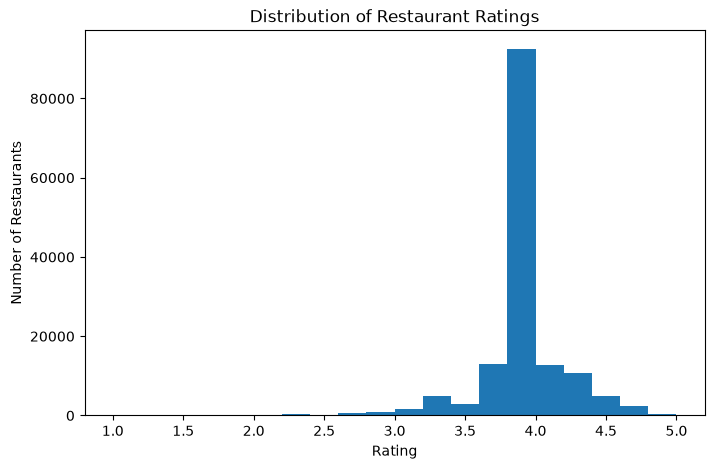

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["rating"], bins=20)

plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurant Ratings")

plt.show()

### "Most restaurants have ratings between 3.5 and 4.5, with the highest concentration around 3.8 to 4.0. Very few restaurants have extremely low or extremely high ratings."

### Cost distribution

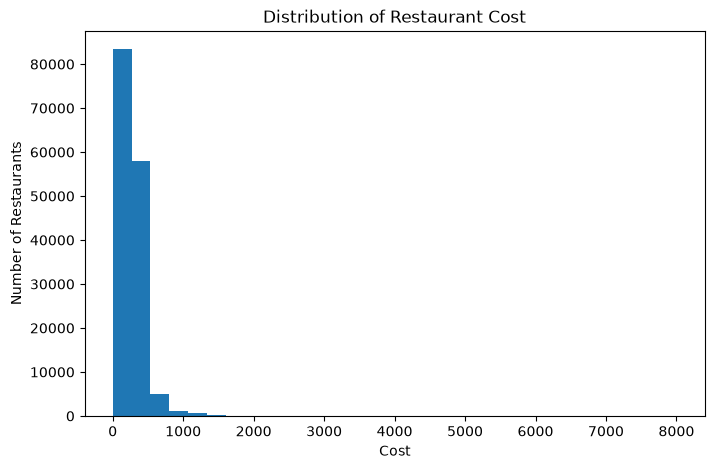

In [63]:
plt.figure(figsize=(8, 5))

plt.hist(df["cost"], bins=30)

plt.xlabel("Cost")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurant Cost")

plt.show()

### "The cost distribution is right-skewed. Most restaurants have costs between ₹100 and ₹500, while a small number of premium restaurants have much higher costs. I identified an extreme value of ₹300,350 during data cleaning and replaced it with the median reasonable cost.

### Top 10 cities

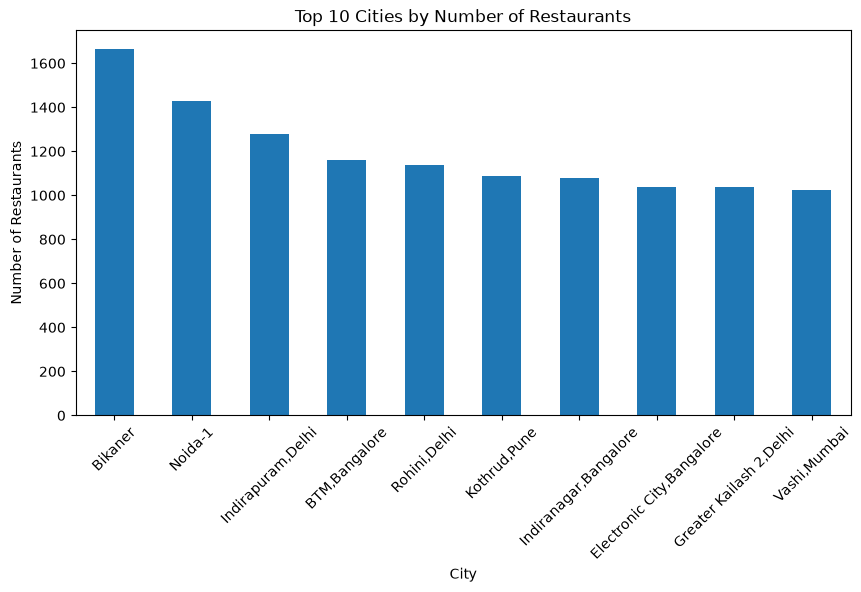

In [64]:
top_cities = df["city"].value_counts().head(10)

plt.figure(figsize=(10, 5))

top_cities.plot(kind="bar")

plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.title("Top 10 Cities by Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

### "The dataset contains 821 unique location values. The locations with the highest number of restaurants include Bikaner, Noida-1, Indirapuram, Delhi and several Bangalore and Delhi localities. The city field contains both city names and locality-city combinations, so I retained the original values."

### Top 10 cuisine combinations

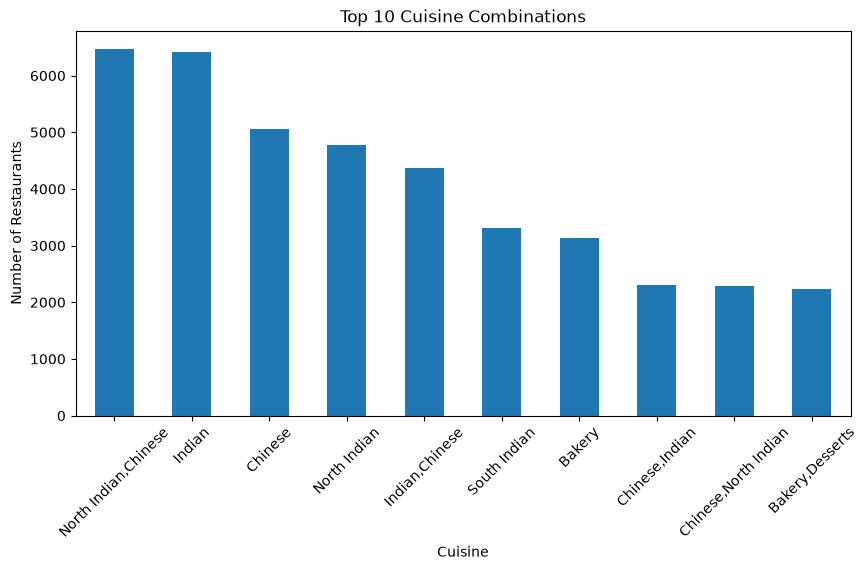

In [65]:
top_cuisines = df["cuisine"].value_counts().head(10)

plt.figure(figsize=(10, 5))

top_cuisines.plot(kind="bar")

plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.title("Top 10 Cuisine Combinations")

plt.xticks(rotation=45)

plt.show()

### 🎉 EDA is finished.

# Encoding

In [66]:
# Import preprocessing libraries

In [67]:
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
import pandas as pd
import numpy as np
import pickle
import os

In [68]:
# Select the features
# Numerical

numerical_features = [
    "rating",
    "rating_count",
    "cost"
]

In [69]:
#Categorical
categorical_features = [
    "city",
    "cuisine"
]

In [70]:
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['rating', 'rating_count', 'cost']
Categorical features: ['city', 'cuisine']


In [71]:
#Prepare the city data

#For city, we'll use the required OneHotEncoder.

city_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

city_encoded = city_encoder.fit_transform(
    df[["city"]]
)

print("City encoded shape:", city_encoded.shape)

City encoded shape: (148532, 821)


In [72]:
# Prepare the cuisine data
cuisine_lists = df["cuisine"].apply(
    lambda x: [
        cuisine.strip()
        for cuisine in x.split(",")
    ]
)
# exp :For example:

# North Indian,Chinese

# becomes:

# ["North Indian", "Chinese"]

In [73]:
# create the multi-hot encoder:
cuisine_encoder = MultiLabelBinarizer()

cuisine_encoded = cuisine_encoder.fit_transform(
    cuisine_lists
)

print("Cuisine encoded shape:", cuisine_encoded.shape)

Cuisine encoded shape: (148532, 123)


In [74]:
print("Number of cuisine features:", len(cuisine_encoder.classes_))

Number of cuisine features: 123


# Scaling

In [75]:
# Scale numerical features

# This is important because our numerical features have very different scales.

# For example:

# rating       → 1–5
# rating_count → 1–500
# cost         → 1–8000

In [76]:
scaler = StandardScaler()

numerical_scaled = scaler.fit_transform(
    df[numerical_features]
)

print("Numerical scaled shape:", numerical_scaled.shape)

Numerical scaled shape: (148532, 3)


In [77]:
encoded_array = np.hstack([
    numerical_scaled,
    city_encoded,
    cuisine_encoded
])

print("Final encoded shape:", encoded_array.shape)

Final encoded shape: (148532, 947)


In [78]:
print("Numerical:", numerical_scaled.shape)
print("City:", city_encoded.shape)
print("Cuisine:", cuisine_encoded.shape)
print("Final:", encoded_array.shape)

Numerical: (148532, 3)
City: (148532, 821)
Cuisine: (148532, 123)
Final: (148532, 947)


In [79]:
# Create encoded_df with the same index

encoded_df = pd.DataFrame(
    encoded_array,
    index=df.index
)

print("Cleaned rows:", len(df))
print("Encoded rows:", len(encoded_df))

print("Same index:", df.index.equals(encoded_df.index))

Cleaned rows: 148532
Encoded rows: 148532
Same index: True


In [80]:
print("First 5 cleaned indices:", df.index[:5].tolist())
print("First 5 encoded indices:", encoded_df.index[:5].tolist())

print("Last 5 cleaned indices:", df.index[-5:].tolist())
print("Last 5 encoded indices:", encoded_df.index[-5:].tolist())

First 5 cleaned indices: [0, 1, 2, 3, 4]
First 5 encoded indices: [0, 1, 2, 3, 4]
Last 5 cleaned indices: [148527, 148528, 148529, 148530, 148531]
Last 5 encoded indices: [148527, 148528, 148529, 148530, 148531]


In [81]:
# save the encoded dataset
encoded_df.to_csv(
    "data/encoded_data.csv",
    index=True
)

print("encoded_data.csv saved successfully!")
print("Shape:", encoded_df.shape)

encoded_data.csv saved successfully!
Shape: (148532, 947)


In [82]:
# save preprocessing objects:
os.makedirs("models", exist_ok=True)

preprocessing_objects = {
    "city_encoder": city_encoder,
    "cuisine_encoder": cuisine_encoder,
    "scaler": scaler
}

with open("models/encoder.pkl", "wb") as file:
    pickle.dump(preprocessing_objects, file)

print("encoder.pkl saved successfully!")

encoder.pkl saved successfully!


In [83]:
# Verify both files
print("Cleaned data shape:", df.shape)
print("Encoded data shape:", encoded_df.shape)

print("Same index:",
      df.index.equals(encoded_df.index))

Cleaned data shape: (148532, 11)
Encoded data shape: (148532, 947)
Same index: True


### Evaluation metrics

In [84]:
from sklearn.metrics.pairwise import cosine_similarity

# Create cuisine sets for easy comparison
cuisine_sets = df["cuisine"].apply(
    lambda x: set(
        cuisine.strip().lower()
        for cuisine in str(x).split(",")
    )
)

# Group restaurant indices by city
city_groups = df.groupby("city").groups


def get_relevant_indices(query_index):

    query_row = df.loc[query_index]

    query_city = query_row["city"]
    query_cost = query_row["cost"]
    query_cuisines = cuisine_sets.loc[query_index]

    candidate_indices = city_groups.get(
        query_city,
        []
    )

    relevant_indices = []

    for idx in candidate_indices:

        if idx == query_index:
            continue

        common_cuisine = bool(
            query_cuisines.intersection(
                cuisine_sets.loc[idx]
            )
        )

        similar_cost = (
            abs(
                df.loc[idx, "cost"] - query_cost
            ) <= 100
        )

        if common_cuisine and similar_cost:
            relevant_indices.append(idx)

    return set(relevant_indices)

### Get Top-K recommendations using cosine similarity

In [85]:
def get_top_k_recommendations(query_index, k=5):

    query_vector = encoded_array[
        query_index
    ].reshape(1, -1)

    similarity_scores = cosine_similarity(
        query_vector,
        encoded_array
    )[0]

    # Do not recommend the restaurant itself
    similarity_scores[query_index] = -1

    top_indices = np.argsort(
        similarity_scores
    )[::-1][:k]

    return top_indices

### Precision, Recall and NDCG

In [86]:
def precision_at_k(query_index, k=5):

    recommended_indices = (
        get_top_k_recommendations(
            query_index,
            k
        )
    )

    relevant_indices = (
        get_relevant_indices(
            query_index
        )
    )

    relevant_recommendations = sum(
        idx in relevant_indices
        for idx in recommended_indices
    )

    return relevant_recommendations / k


def recall_at_k(query_index, k=5):

    relevant_indices = (
        get_relevant_indices(
            query_index
        )
    )

    if len(relevant_indices) == 0:
        return None

    recommended_indices = (
        get_top_k_recommendations(
            query_index,
            k
        )
    )

    relevant_recommendations = sum(
        idx in relevant_indices
        for idx in recommended_indices
    )

    return (
        relevant_recommendations /
        len(relevant_indices)
    )


def ndcg_at_k(query_index, k=5):

    relevant_indices = (
        get_relevant_indices(
            query_index
        )
    )

    recommended_indices = (
        get_top_k_recommendations(
            query_index,
            k
        )
    )

    relevance = np.array([
        1 if idx in relevant_indices else 0
        for idx in recommended_indices
    ])

    if relevance.sum() == 0:
        return 0.0

    dcg = np.sum(
        relevance /
        np.log2(
            np.arange(2, k + 2)
        )
    )

    ideal_relevance = np.sort(
        relevance
    )[::-1]

    ideal_dcg = np.sum(
        ideal_relevance /
        np.log2(
            np.arange(2, k + 2)
        )
    )

    return (
        dcg / ideal_dcg
        if ideal_dcg > 0
        else 0.0
    )

### Evaluate a sample

In [87]:
np.random.seed(42)

sample_indices = np.random.choice(
    df.index,
    size=50,
    replace=False
)

precision_scores = []
recall_scores = []
ndcg_scores = []

for query_index in sample_indices:

    precision_scores.append(
        precision_at_k(
            query_index,
            k=5
        )
    )

    recall = recall_at_k(
        query_index,
        k=5
    )

    if recall is not None:
        recall_scores.append(
            recall
        )

    ndcg_scores.append(
        ndcg_at_k(
            query_index,
            k=5
        )
    )

In [88]:
average_precision = np.mean(
    precision_scores
)

average_recall = np.mean(
    recall_scores
)

average_ndcg = np.mean(
    ndcg_scores
)

print("Recommendation Evaluation")
print("-------------------------")

print(
    f"Precision@5: "
    f"{average_precision:.4f}"
)

print(
    f"Recall@5: "
    f"{average_recall:.4f}"
)

print(
    f"NDCG@5: "
    f"{average_ndcg:.4f}"
)

Recommendation Evaluation
-------------------------
Precision@5: 0.7400
Recall@5: 0.1132
NDCG@5: 0.9054


### Checking similarity score of dummy user input

In [92]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ==========================================
# SAMPLE PREDICTION WITH DUMMY USER INPUT
# ==========================================

my_request = {
    "city": "Mumbai",
    "cuisine": "Italian",
    "rating": 4.5,
    "rating_count": 100,
    "cost": 500
}


# 1. Scale numerical features
numerical_input = np.array([[
    my_request["rating"],
    my_request["rating_count"],
    my_request["cost"]
]])

numerical_scaled = scaler.transform(numerical_input)


# 2. Encode city
city_encoded = city_encoder.transform(
    [[my_request["city"]]]
)

city_encoded = np.asarray(city_encoded)


# 3. Encode cuisine
cuisine_encoded = cuisine_encoder.transform(
    [[my_request["cuisine"]]]
)

cuisine_encoded = np.asarray(cuisine_encoded)


# 4. Combine all features
user_vector = np.hstack([
    numerical_scaled,
    city_encoded,
    cuisine_encoded
])


# 5. Calculate cosine similarity
similarity_scores = cosine_similarity(
    user_vector,
    encoded_array
)[0]


# 6. Get top 5 restaurants
top_indices = np.argsort(
    similarity_scores
)[::-1][:5]


# 7. Display recommendations
recommendations = df.loc[
    top_indices,
    [
        "name",
        "city",
        "rating",
        "rating_count",
        "cost",
        "cuisine"
    ]
].copy()


# 8. Add similarity score
recommendations["similarity_score"] = (
    similarity_scores[top_indices]
)

recommendations

c:\Users\LENOVO\Desktop\GUVI\guvi_fourth_project_final\swiggy_final\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\GUVI\guvi_fourth_project_final\swiggy_final\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


,name,city,rating,rating_count,cost,cuisine,similarity_score
13623,Bologna Italian Restaurant,"Indiranagar,Bangalore",4.5,100.0,600.0,Italian,0.932298
79756,Pa se Pizza,"Kukatpally,Hyderabad",4.9,50.0,600.0,"Pizzas,Italian",0.930631
68751,HOT STONE,"sohna road,Gurgaon",5.0,20.0,600.0,"Pizzas,Italian",0.930508
50997,Francesco's Pizzeria,"Greater Kailash 2,Delhi",4.8,20.0,700.0,"Pizzas,Italian",0.924269
61328,Nomad Pizza- Traveller Series,"Malviya Nagar,Delhi",4.9,20.0,850.0,"Pizzas,Italian",0.919343
